<div style="border:solid green 2px; padding: 20px"> <h1 style="color:green; margin-bottom:20px">Reviewer's comment v1</h1>

Hello Avon!

I'm happy to review your project today  🙌

My name is **Gerardo Flores** and you can find me on the HUB as https://hub.tripleten.com/u/1949959f

You can find my comments under the heading **«Review»**. I will categorize my comments in green, blue or red boxes like this:

<div class="alert alert-success">
    <b>Success:</b> if everything is done successfully
</div>
<div class="alert alert-warning">
    <b>Remarks:</b> if I can give some recommendations or ways to improve the project
</div>
<div class="alert alert-danger">
    <b>Needs fixing:</b> if the block requires some corrections. Work can't be accepted with the red comments
</div>

Please don't remove my comments. If you have any questions, don't hesitate to respond to my comments in a different section.
<div class="alert alert-info"> <b>Student comments: </div>    


<div style="border:solid red 2px; padding: 20px">
<b>Reviewer's comment v1:</b>

    
<b>Overall Feedback</b>
    
Hello Avon,
    
You’ve submitted another project—great work! Your commitment to pushing through the challenges of this program is admirable.

After reviewing your submission, I’ve returned it with some feedback to help you make the necessary improvements.
    
   
You can find my more detailed notes within your project notebook in the `Reviewer's comment v1:` section.

Keep in mind that revisions are a normal and valuable part of the learning process. Use this feedback to refine your work and resubmit when you’re ready. I know you’re capable of great things, and I’m here to support you every step of the way. Keep going—you’re doing a great job! 🏄

If you find yourself uncertain or in need of further insights, never hesitate to consult with your tutor or ask your questions here. We are here to guide and assist you.

<div style="border:solid green 2px; padding: 20px">
<b>Reviewer's comment v2:</b>

    
<b>Overall Feedback</b>
    
Hello Avon,
    
You’ve submitted another project—great work! Your commitment to pushing through the challenges of this program is admirable.

After reviewing your submission, it is approved.
    
   
You can find my more detailed notes within your project notebook in the `Reviewer's comment v1:` section.

If you find yourself uncertain or in need of further insights, never hesitate to consult with your tutor or ask your questions here. We are here to guide and assist you.

**Initial plan: Add *'tenure_month'* column using *['BeginDate', 'EndDate']*, drop *'gender'* column**

*notes:*

target is 5,174 (active) : 1,869 (churned) / 7,043 (total)... (~27%)... class_weight='balanced'

stratify=target... maintain the ~27% imbalance environment for train/test sets

In [1]:
import pandas as pd
import numpy as np
import math as mt
import warnings
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import sklearn.metrics as metrics
from sklearn.utils import shuffle
#from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import VotingClassifier

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

data_contract = pd.read_csv('contract.csv')
data_internet = pd.read_csv('internet.csv')
data_personal = pd.read_csv('personal.csv')
data_phone = pd.read_csv('phone.csv')

display(data_contract.head())
display(data_internet.head())
display(data_personal.head())
display(data_phone.head())

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [2]:
    #!! converting date columns to datetime format
warnings.filterwarnings('ignore')
data_contract['BeginDate'] = pd.to_datetime(data_contract['BeginDate'])
data_contract['EndDate'] = pd.to_datetime(data_contract['EndDate'], errors='coerce')
warnings.filterwarnings('default')

    #!! filling NaT (EndDate = 'No') with 'current day' (data set extraction date 2020-02-01)
data_contract['EndDate'] = data_contract['EndDate'].fillna(pd.Timestamp('2020-02-01'))

    #!! calculating tenure in months
data_contract['tenure_month'] = (data_contract['EndDate'] - data_contract['BeginDate']).dt.days // 30

    #!! dropping BeginDate (no relationship with customer loyalty)
data_contract = data_contract.drop('BeginDate', axis=1)

    #!! converting TotalCharges to numeric, coercing errors to NaN, then filling NaN with 0
data_contract['TotalCharges'] = pd.to_numeric(data_contract['TotalCharges'], errors='coerce')
data_contract['TotalCharges'] = data_contract['TotalCharges'].fillna(0)

    #!! converting EndDate to boolean (int64): 0 = active (2020-02-01), 1 = churned (other dates)
data_contract['EndDate'] = data_contract['EndDate'].apply(lambda x: 0 if x == pd.Timestamp('2020-02-01') else 1)

    #!! data_contract columns renamed, EndDate to churned, Type to contract_type, rest snake case
data_contract.rename(columns={'EndDate': 'churned', 'Type': 'contract_type', 'PaperlessBilling': 'paperless_billing',
                              'PaymentMethod': 'payment_method', 'MonthlyCharges': 'monthly_charges',
                              'TotalCharges': 'total_charges'}, inplace=True)

    #!! converting 'Yes'/'No' to 1/0
data_contract['paperless_billing'] = (data_contract['paperless_billing'] == 'Yes').astype(int)

display(data_contract.head())

,customerID,churned,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,tenure_month
0,7590-VHVEG,0,Month-to-month,1,Electronic check,29.85,29.85,1
1,5575-GNVDE,0,One year,0,Mailed check,56.95,1889.50,34
2,3668-QPYBK,1,Month-to-month,1,Mailed check,53.85,108.15,2
3,7795-CFOCW,0,One year,0,Bank transfer (automatic),42.30,1840.75,45
4,9237-HQITU,1,Month-to-month,1,Electronic check,70.70,151.65,2


**- *['tenure_month']* column added using 'BeginDate' & 'EndDate'... *['BeginDate']* dropped for reasons specified above... *['EndDate']* converted into binary int64 column where (0 = active, 1 = churned)... *['EndDate']* renamed to *['churned']*, and all columns converted to snake case (except customerID)... *['paperless_billing']* converted to binary column (1/0 - yes/no)**

In [3]:
    #!! data_internet columns renamed
data_internet.rename(columns={'InternetService': 'internet_service', 'OnlineSecurity': 'online_security',
                              'OnlineBackup': 'online_backup', 'DeviceProtection': 'device_protection',
                              'TechSupport': 'tech_support', 'StreamingTV': 'streaming_tv',
                              'StreamingMovies': 'streaming_movies'}, inplace=True)

**- all columns within the internet.csv data set have been converted to snake case**

In [4]:
    #!! dropping gender column (no relationship with customer loyalty)
data_personal = data_personal.drop('gender', axis=1)

    #!! data_personal columns renamed
data_personal.rename(columns={'SeniorCitizen': 'senior_citizen', 'Partner': 'partner',
                              'Dependents': 'dependents'}, inplace=True)

    #!! converting 'Yes'/'No' to 1/0
data_personal['partner'] = (data_personal['partner'] == 'Yes').astype(int)
data_personal['dependents'] = (data_personal['dependents'] == 'Yes').astype(int)

**- *['gender']* has been dropped from the peronal.csv data set, since it has no predictive power in the context of customer retention... all columns converted to snake case... *['partner', 'dependents']* converted to binary int64 (1/0 - yes/no)**

In [5]:
    #!! data_phone columns renamed
data_phone.rename(columns={'MultipleLines': 'multiple_lines'}, inplace=True)

**- snake case conversion for phone.csv column**

In [6]:
#data_contract.info()
#data_internet.info()
#data_personal.info()
#data_phone.info()

display(data_contract.head())
display(data_internet.head())
display(data_personal.head())
display(data_phone.head())

    #!! checking unique values
#for col in data_contract.select_dtypes(include=['object', 'int64']).columns: display(data_contract[col].value_counts())

    #!! checking unique values
#for col in data_internet.select_dtypes(include=['object']).columns: display(data_internet[col].value_counts())

    #!! checking unique values
#for col in data_personal.select_dtypes(include=['object', 'int64']).columns: display(data_personal[col].value_counts())

    #!! checking unique values
#for col in data_phone.select_dtypes(include=['object']).columns: display(data_phone[col].value_counts())

,customerID,churned,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,tenure_month
0,7590-VHVEG,0,Month-to-month,1,Electronic check,29.85,29.85,1
1,5575-GNVDE,0,One year,0,Mailed check,56.95,1889.50,34
2,3668-QPYBK,1,Month-to-month,1,Mailed check,53.85,108.15,2
3,7795-CFOCW,0,One year,0,Bank transfer (automatic),42.30,1840.75,45
4,9237-HQITU,1,Month-to-month,1,Electronic check,70.70,151.65,2


,customerID,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


,customerID,senior_citizen,partner,dependents
0,7590-VHVEG,0,1,0
1,5575-GNVDE,0,0,0
2,3668-QPYBK,0,0,0
3,7795-CFOCW,0,0,0
4,9237-HQITU,0,0,0


,customerID,multiple_lines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


**- misc print and display loops to monitor the integrity of our features**

In [7]:
    #!! merging all dataframes on customerID
data = data_contract.merge(
    data_internet, on='customerID', how='left').merge(
        data_personal, on='customerID', how='left').merge(
            data_phone, on='customerID', how='left')

#data.info()
#display(data.head())
#display(data['multiple_lines'].value_counts())

    #!! converting add-on services 'Yes'/'No' to 1/0
add_ons = ['online_security', 'online_backup', 'device_protection',
            'tech_support', 'streaming_tv', 'streaming_movies']
data[add_ons] = data[add_ons].applymap(lambda x: 1 if x == 'Yes' else 0)

    #!! filling 'No Service' for NaN values (customers without internet or phone service)
data.fillna('No Service', inplace=True)

    #!! flagging high risk customers (electronic check, month-to-month, paperless billing)
data['high_risk'] = ((data['payment_method'] == 'Electronic check')
                     & (data['contract_type'] == 'Month-to-month')
                     & (data['paperless_billing'] == 1)).astype(int)

    #!! flagging low risk customers (long tenure, non-month-to-month, no paperless billing)
data['low_risk'] = ((data['tenure_month'] >= 12)
                    & (data['paperless_billing'] == 0)
                    & (data['contract_type'] != 'Month-to-month')).astype(int)

#data.info()
display(data.head())
#display(data['multiple_lines'].value_counts())

C:\Users\avonm\AppData\Local\Temp\ipykernel_8672\3571330794.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data[add_ons] = data[add_ons].applymap(lambda x: 1 if x == 'Yes' else 0)


,customerID,churned,contract_type,paperless_billing,payment_method,monthly_charges,total_charges,tenure_month,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,senior_citizen,partner,dependents,multiple_lines,high_risk,low_risk
0,7590-VHVEG,0,Month-to-month,1,Electronic check,29.85,29.85,1,DSL,0,...,0,0,0,0,0,1,0,No Service,1,0
1,5575-GNVDE,0,One year,0,Mailed check,56.95,1889.50,34,DSL,1,...,1,0,0,0,0,0,0,No,0,1
2,3668-QPYBK,1,Month-to-month,1,Mailed check,53.85,108.15,2,DSL,1,...,0,0,0,0,0,0,0,No,0,0
3,7795-CFOCW,0,One year,0,Bank transfer (automatic),42.30,1840.75,45,DSL,1,...,1,1,0,0,0,0,0,No Service,0,1
4,9237-HQITU,1,Month-to-month,1,Electronic check,70.70,151.65,2,Fiber optic,0,...,0,0,0,0,0,0,0,No,1,0


**- all 4 data sets merged on *'customerID'*, using contract.csv as the merge root... 'add_ons' concerning additional services have been converted to binary int64 (1/0 - yes/no)... *'No Service'* filling in missing values for *['internet_service', 'multiple_lines']* where customers have one or the other... *['high_risk', 'low_risk']* features added using columns that correlate strongly with the target variable**

In [8]:
#display(data[(data['payment_method'] == 'Electronic check') & (data['contract_type'] == 'Month-to-month')
#             & (data['paperless_billing'] == 1)]['churned'].value_counts())

#display(data[(data['tenure_month'] >= 12) & (data['paperless_billing'] == 0)
#             & (data['contract_type'] != 'Month-to-month')]['churned'].value_counts())

In [9]:
    #!! OHE categorical features, dropping customerID
data_ohe = pd.get_dummies(data.drop('customerID', axis=1), drop_first=True)

features = data_ohe.drop('churned', axis=1)
target = data_ohe['churned']

    #!! splitting data into train and valid sets (60/40), stratifying on target variable 'churned' (imbalanced classes)
train_features, valid_features, train_target, valid_target = train_test_split(features, target, test_size=0.4, random_state=777, stratify=target)

    #!! splitting valid set into validation and test sets (50/50 of 40%), stratifying on target variable 'churned' (imbalanced classes)
valid_features, test_features, valid_target, test_target = train_test_split(valid_features, valid_target, test_size=0.5, random_state=777, stratify=valid_target)

**- categorical features encoded using OHE... data split 60/20/20 : train/valid/test sets... stratifying on our target variable to maintain the 27% churn class imbalance... data ready for model training**

In [10]:
#!! applying SMOTE class balancing to training set
#warnings.filterwarnings('ignore')
#smote = SMOTE(random_state=777)
#train_features, train_target = smote.fit_resample(train_features, train_target)
#warnings.filterwarnings('default')

#!! upsampling minority class observations
#def upsample(features, target, repeat):
#    features_zeros = features[target == 0]
#    features_ones = features[target == 1]
#    target_zeros = target[target == 0]
#    target_ones = target[target == 1]
#	
#    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
#    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)
#	
#    features_upsampled, target_upsampled = shuffle(features_upsampled, 
#                                                   target_upsampled,
#                                                   random_state=777)
#	
#    return features_upsampled, target_upsampled
#
#train_features, train_target = upsample(train_features, train_target, 3)

#!! downsampling majority class observations
#def downsample(features, target, fraction):
#    features_zeros = features[target == 0]
#    features_ones = features[target == 1]
#    target_zeros = target[target == 0]
#    target_ones = target[target == 1]
#
#    features_downsampled = pd.concat(
#        [features_zeros.sample(frac=fraction, random_state=12345)] + [features_ones])
#    
#    target_downsampled = pd.concat(
#        [target_zeros.sample(frac=fraction, random_state=12345)] + [target_ones])
#	
#    features_downsampled, target_downsampled = shuffle(
#        features_downsampled, target_downsampled, random_state=777)
#
#    return features_downsampled, target_downsampled
#
#train_features, train_target = downsample(train_features, train_target, 0.2)

**- showing my attempts at different class balancing methods, in the end, specifying class imbalance directly to the machine through hyperparameters gave the best results**

In [11]:
    #!! initiating StandardScaler
#numeric = ['monthly_charges', 'total_charges', 'tenure_month']
#scaler = StandardScaler()
#scaler.fit(train_features[numeric])

    #!! scaling non-binary numeric columns
#train_features[numeric] = scaler.transform(train_features[numeric])
#valid_features[numeric] = scaler.transform(valid_features[numeric])
#test_features[numeric] = scaler.transform(test_features[numeric])

**- numerical scaling is not necessary for tree-based algorithms, which account for all of our top performers in this project**

In [12]:
display(data_ohe.head())
#display(data_ohe.info())

display(train_features.head())
#print(train_features.info())
#print(train_target.value_counts())

display(valid_features.head())
#print(valid_features.info())
#print(valid_target.value_counts())

display(test_features.head())
#print(test_features.info())
#print(test_target.value_counts())

,churned,paperless_billing,monthly_charges,total_charges,tenure_month,online_security,online_backup,device_protection,tech_support,streaming_tv,...,low_risk,contract_type_One year,contract_type_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check,internet_service_Fiber optic,internet_service_No Service,multiple_lines_No Service,multiple_lines_Yes
0,0,1,29.85,29.85,1,0,1,0,0,0,...,0,False,False,False,True,False,False,False,True,False
1,0,0,56.95,1889.50,34,1,0,1,0,0,...,1,True,False,False,False,True,False,False,False,False
2,1,1,53.85,108.15,2,1,1,0,0,0,...,0,False,False,False,False,True,False,False,False,False
3,0,0,42.30,1840.75,45,1,0,1,1,0,...,1,True,False,False,False,False,False,False,True,False
4,1,1,70.70,151.65,2,0,0,0,0,0,...,0,False,False,False,True,False,True,False,False,False


,paperless_billing,monthly_charges,total_charges,tenure_month,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,...,low_risk,contract_type_One year,contract_type_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check,internet_service_Fiber optic,internet_service_No Service,multiple_lines_No Service,multiple_lines_Yes
2490,0,100.55,3895.35,39,0,0,0,1,1,1,...,1,False,True,False,False,True,True,False,False,True
593,1,84.30,2438.60,30,1,1,1,0,0,0,...,0,False,False,True,False,False,True,False,False,False
5490,1,55.70,335.65,6,1,1,0,0,0,0,...,0,False,False,False,False,False,False,False,False,False
4595,0,85.30,5560.00,69,0,1,1,1,1,1,...,1,False,True,False,False,False,False,False,False,True
2903,0,35.50,432.25,12,0,1,0,1,0,0,...,0,False,False,False,False,True,False,False,True,False


,paperless_billing,monthly_charges,total_charges,tenure_month,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,...,low_risk,contract_type_One year,contract_type_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check,internet_service_Fiber optic,internet_service_No Service,multiple_lines_No Service,multiple_lines_Yes
92,1,84.00,5714.25,67,1,0,1,1,1,1,...,0,False,True,False,False,True,False,False,False,True
4256,1,26.00,2006.95,71,0,0,0,0,0,0,...,0,False,True,False,False,False,False,True,False,True
3213,0,35.40,1412.40,41,1,0,1,0,0,0,...,1,True,False,True,False,False,False,False,True,False
847,0,33.15,444.75,12,1,0,0,1,0,0,...,1,True,False,True,False,False,False,False,True,False
6821,1,99.85,1776.95,18,0,0,0,1,1,1,...,0,False,False,False,False,False,True,False,False,True


,paperless_billing,monthly_charges,total_charges,tenure_month,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,...,low_risk,contract_type_One year,contract_type_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check,internet_service_Fiber optic,internet_service_No Service,multiple_lines_No Service,multiple_lines_Yes
5507,1,59.90,1654.70,28,1,1,0,1,0,0,...,0,True,False,False,True,False,False,False,False,False
2601,1,98.65,7129.45,73,0,1,1,1,0,1,...,0,False,True,False,False,False,True,False,False,True
3180,0,20.00,63.60,3,0,0,0,0,0,0,...,0,False,False,False,False,True,False,True,False,False
6481,0,69.95,320.40,5,0,0,0,0,0,0,...,0,False,False,True,False,False,True,False,False,False
2200,0,58.20,1045.25,19,0,1,0,0,1,0,...,1,True,False,False,True,False,False,False,False,False


In [13]:
#!! function to evaluate classification model performance (Accuracy, F1, APS, ROC-AUC) with plots (F1, ROC, PRC)
def evaluate_model(model, train_features, train_target, test_features, test_target):

    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(4)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

**- function from previous project used to evaluate binary classification models under various metrics... including the primary metric used for this project evaluation (ROC-AUC >= .85)... modified for 4 decimal places**

## Baseline Model: DummyClassifier

           train    test
Accuracy  0.7347  0.7346
F1        0.0000  0.0000
APS       0.2653  0.2654
ROC AUC   0.5000  0.5000


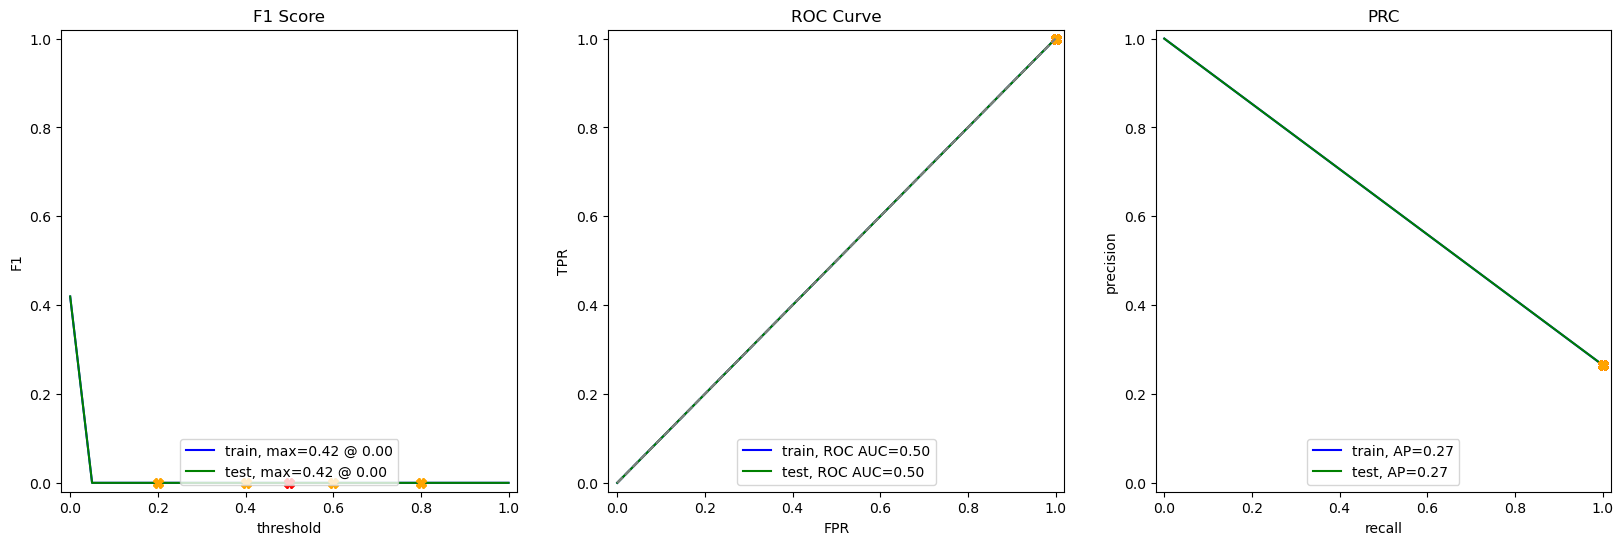

In [14]:
    #!! establishing baseline model (Dummy Classifier)
dummy_model = DummyClassifier(strategy='most_frequent', random_state=777)
dummy_model.fit(train_features, train_target)

evaluate_model(dummy_model, train_features, train_target, valid_features, valid_target)

**- As expected, predicting the majority class (0 = active) for every observation will result in being correct 73% of the time, this also means our model has no capability to distinguish between classes, hence the .50 ROC-AUC score**

## LogisticRegression

           train    test
Accuracy  0.7536  0.7452
F1        0.6305  0.6249
APS       0.6650  0.6473
ROC AUC   0.8481  0.8392


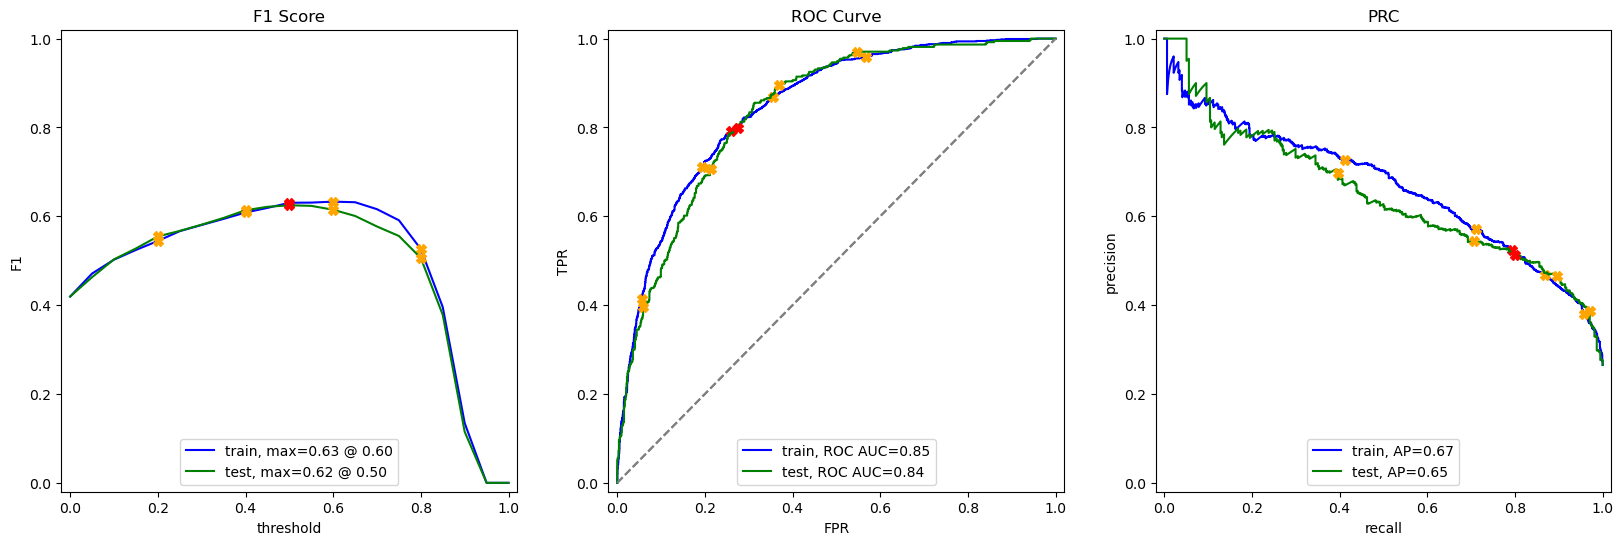

In [15]:
    #!! logistic regression model with balanced class weights
warnings.filterwarnings('ignore')
log_model = LogisticRegression(class_weight='balanced', random_state=777)
log_model.fit(train_features, train_target)
warnings.filterwarnings('default')

evaluate_model(log_model, train_features, train_target, valid_features, valid_target)

**- our accuracy has improved by roughly 1% using LogisticRegression over DummyClassifier, with a ROC-AUC of .8392 on the validation set... LogisticRegression will serve as our model to overcome moving forward**

## DecisionTreeClassifier

Best parameters found:  {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best ROC-AUC score:  0.8232365045971639
           train    test
Accuracy  0.7456  0.7289
F1        0.6208  0.6037
APS       0.6223  0.5912
ROC AUC   0.8468  0.8252


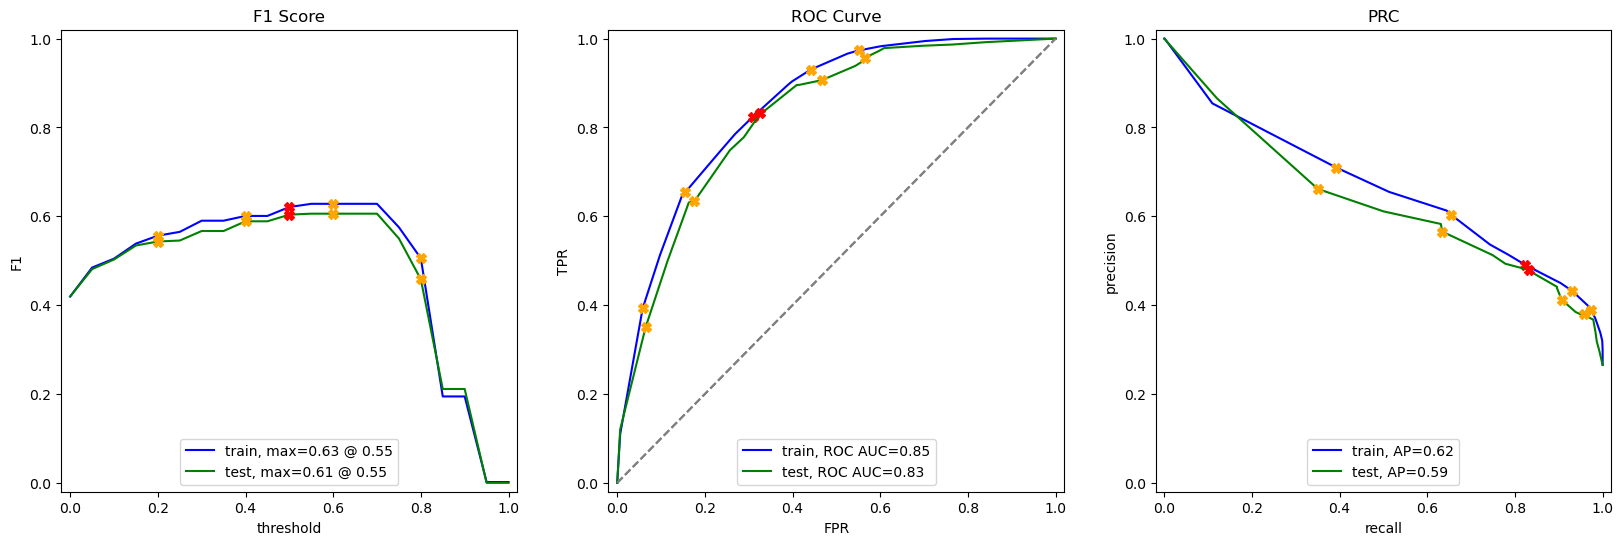

In [16]:
tree_params = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

tree_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=777),
    param_grid=tree_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

tree_grid.fit(train_features, train_target)

print("Best parameters found: ", tree_grid.best_params_)
print("Best ROC-AUC score: ", tree_grid.best_score_)

evaluate_model(tree_grid.best_estimator_, train_features, train_target, valid_features, valid_target)

**- DecisionTreeClassifier scored worse in every metric compared to LogisticRegression, so we will be moving onto RandomForest**

## RandomForestClassifier

Best parameters found:  {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 30}
Best ROC-AUC score:  0.8443027035701298
           train    test
Accuracy  0.7927  0.7502
F1        0.6748  0.6199
APS       0.7450  0.6475
ROC AUC   0.8908  0.8389


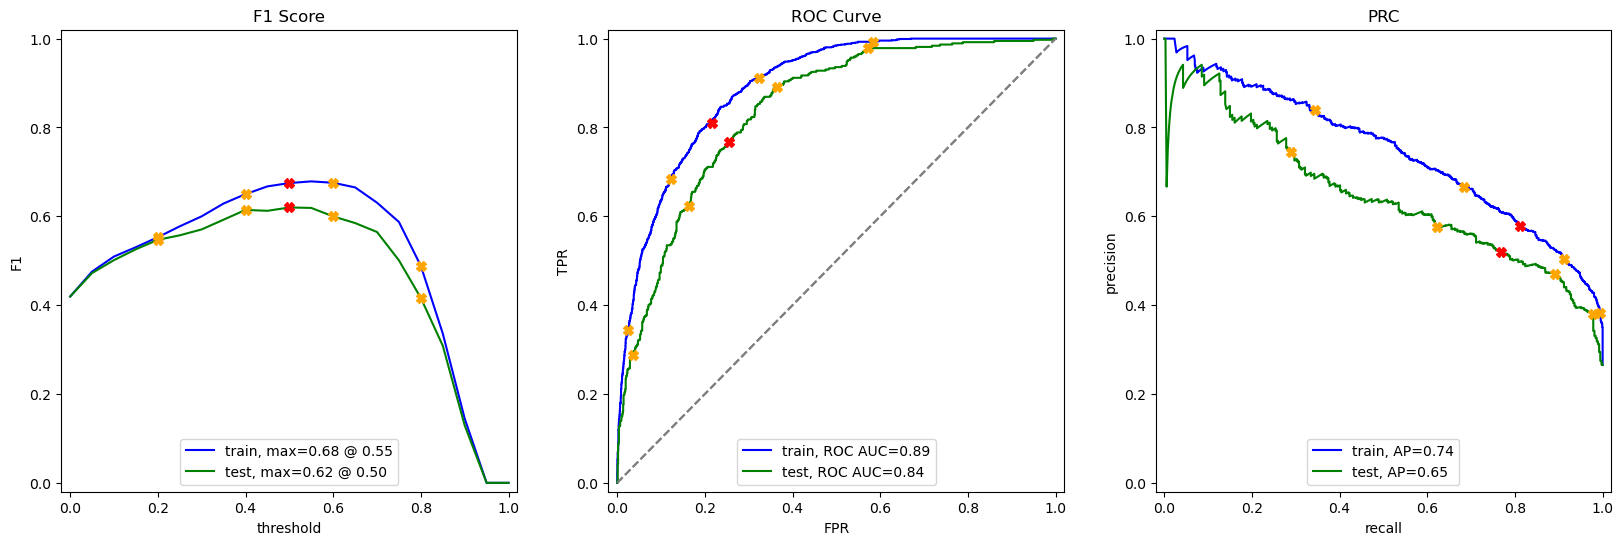

In [17]:
forest_params = {
    'n_estimators': [25, 30, 35, 45],
    'max_depth': [8, 10, 12, 14],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy'],
    'class_weight': [None, 'balanced']
}

forest_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=777),
    param_grid=forest_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

forest_grid.fit(train_features, train_target)

print("Best parameters found: ", forest_grid.best_params_)
print("Best ROC-AUC score: ", forest_grid.best_score_)

evaluate_model(forest_grid.best_estimator_, train_features, train_target, valid_features, valid_target)

**- RandomForestClassifier performs marginally better than DecisionTreeClassifier, but still does not make it to the desired ROC-AUC of .85, we will be moving to more complex boosting models**

## XGBClassifier

           train    test
Accuracy  0.7782  0.7417
F1        0.6681  0.6247
APS       0.7141  0.6645
ROC AUC   0.8808  0.8442


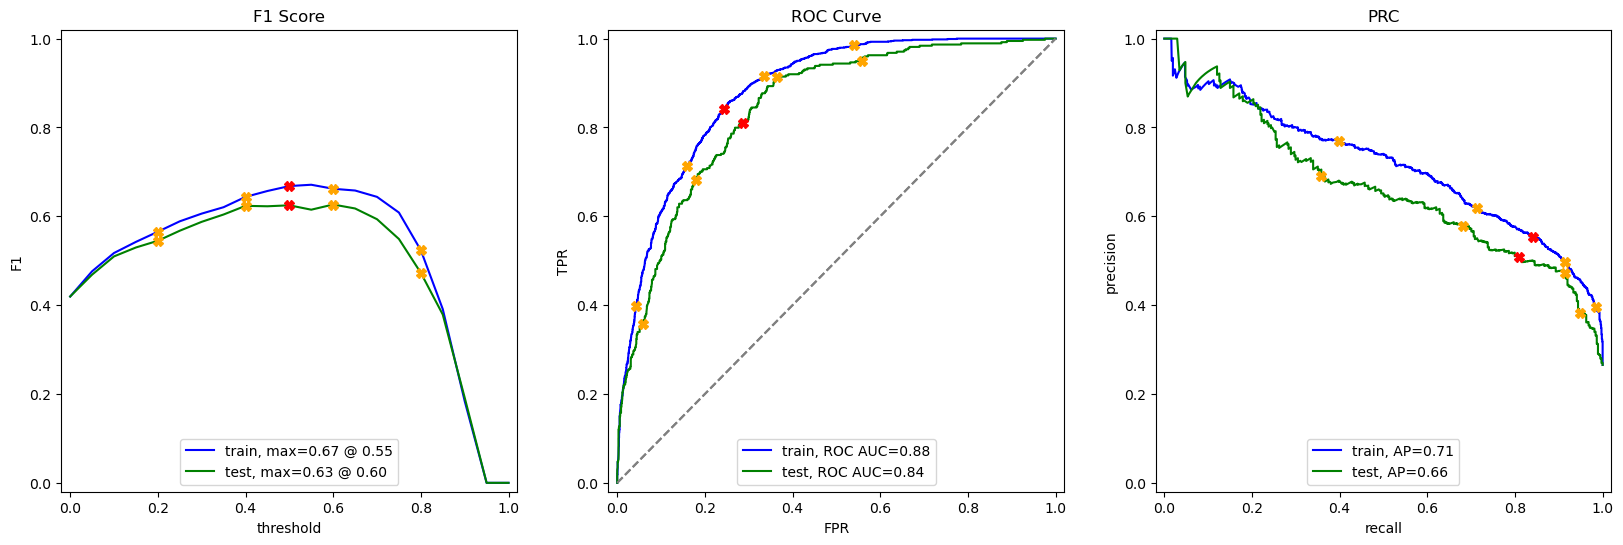

In [18]:
#xgb_params = {
#    'n_estimators': [50, 100, 200],
#    'max_depth': [4, 6, 8],
#    'learning_rate': [0.01, 0.1, 0.2],
#    'scale_pos_weight': [None, 2.768],
#}

#xgb_grid = GridSearchCV(
#    estimator=XGBClassifier(eval_metric='auc', random_state=777),
#    param_grid=xgb_params,
#    scoring='roc_auc',
#    cv=5,
#    n_jobs=-1,
#    verbose=0
#)

#xgb_grid.fit(train_features, train_target)
#print('Best parameters:', xgb_grid.best_params_)
#print('Best ROC-AUC:', xgb_grid.best_score_)

#evaluate_model(xgb_grid.best_estimator_, train_features, train_target, valid_features, valid_target)

xgb_model = XGBClassifier(eval_metric='auc', random_state=777, scale_pos_weight=2.768,
                          n_estimators=50, max_depth=4, learning_rate=0.1)

xgb_model.fit(train_features, train_target)

evaluate_model(xgb_model, train_features, train_target, valid_features, valid_target)

**- XGBoost is performing substantially better than our previous models, but let's try another boost model, and then stack them in an ensemble to see if we can achieve AUC >= .85**

*note for project submission... gridsearch caused the cell to take an indefinite amount of time to train, so I've manually entered the optimal parameters seen at the conclusion section*

## CatBoostClassifier

           train    test
Accuracy  0.7915  0.7431
F1        0.6832  0.6229
APS       0.7360  0.6555
ROC AUC   0.8927  0.8407


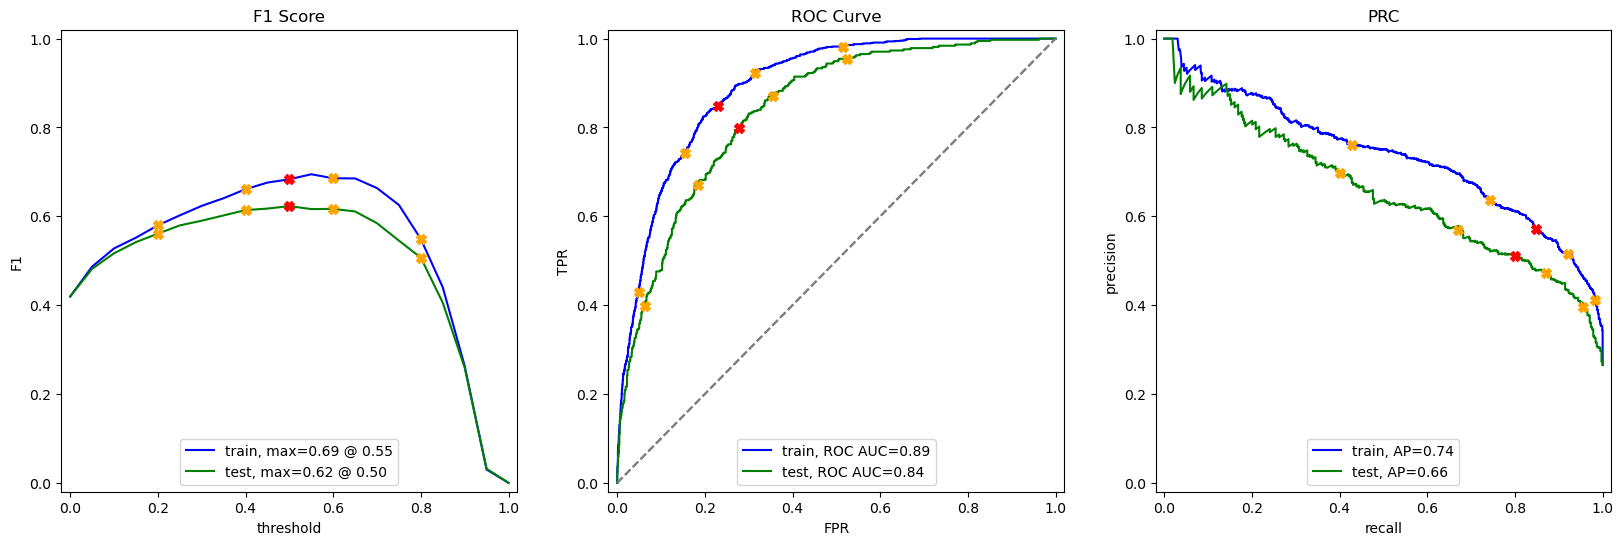

In [19]:
#cbc_params = {
#    'loss_function': ['Logloss', 'CrossEntropy'],
#    'iterations': [50, 100, 200],
#    'depth': [4, 6, 8],
#    'class_weights': [None, [1, 2.768]],
#}

#cbc_grid = GridSearchCV(
#    estimator=CatBoostClassifier(verbose=0, random_state=777),
#    param_grid=cbc_params,
#    scoring='roc_auc',
#    cv=3,
#    n_jobs=-1
#)

#warnings.filterwarnings('ignore')
#cbc_grid.fit(train_features, train_target)
#print('Best parameters:', cbc_grid.best_params_)
#print('Best ROC-AUC:', cbc_grid.best_score_)

#evaluate_model(cbc_grid.best_estimator_, train_features, train_target, valid_features, valid_target)
#warnings.filterwarnings('default')

#important = cbc_grid.best_estimator_.get_feature_importance()
#names = train_features.columns
#important_features = pd.DataFrame({'feature': names, 'importance': important}).sort_values(by='importance', ascending=False)
#display(important_features.head(30))

cbc_model = CatBoostClassifier(verbose=0, random_state=777, depth=4, class_weights=[1, 2.768],
                               iterations=200, loss_function='Logloss')

cbc_model.fit(train_features, train_target)

evaluate_model(cbc_model, train_features, train_target, valid_features, valid_target)

**- CatBoost scores slightly lower in F1 and AUC than XGBoost, but we now have 2 models scoring AUC >= .84, I still think it is worth stacking these 2 powerful models to see if they perform better together rather than independently**

*note for project submission... part 2... gridsearch caused the cell to take an indefinite amount of time to train, so I've manually entered the optimal parameters seen at the conclusion section*

## Ensemble: XGBClassifier, CatBoostClassifier

           train    test
Accuracy  0.7849  0.7438
F1        0.6771  0.6259
APS       0.7274  0.6622
ROC AUC   0.8885  0.8436


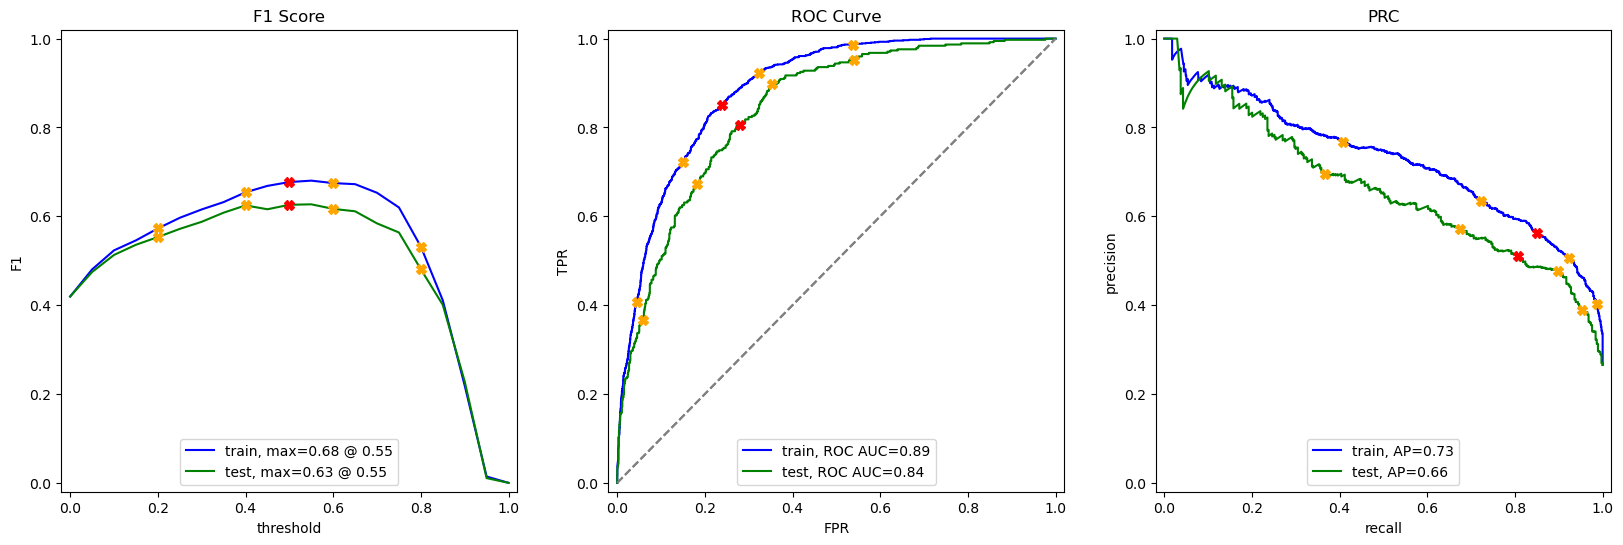

In [20]:
#ensemble = VotingClassifier([
#    ('xgb', XGBClassifier(eval_metric='auc', random_state=777,
#                           n_estimators=xgb_grid.best_params_['n_estimators'],
#                           max_depth=xgb_grid.best_params_['max_depth'],
#                           learning_rate=xgb_grid.best_params_['learning_rate'],
#                           scale_pos_weight=xgb_grid.best_params_['scale_pos_weight'])),
#    ('cbc', CatBoostClassifier(verbose=0, random_state=777,
#                               loss_function=cbc_grid.best_params_['loss_function'],
#                               iterations=cbc_grid.best_params_['iterations'],
#                               depth=cbc_grid.best_params_['depth'],
#                               class_weights=cbc_grid.best_params_['class_weights']))
#], voting='soft')

ensemble = VotingClassifier([
    ('xgb', XGBClassifier(eval_metric='auc', random_state=777, n_estimators=50,
                          max_depth=4, learning_rate=0.1, scale_pos_weight=2.768)),
    ('cbc', CatBoostClassifier(verbose=0, random_state=777, class_weights=[1, 2.768],
                                depth=4, iterations=200, loss_function='Logloss'))
], voting='soft')

ensemble.fit(train_features, train_target)

evaluate_model(ensemble, train_features, train_target, valid_features, valid_target)

**- stacking XGBClassifier and CatBoostClassifier has resulted in the highest metric scores we have seen up this point regarding the validation set, hopefully it performs as well, if not better on the new unseen test set**

## Ensemble Against the Test Set

           train    test
Accuracy  0.7849  0.7658
F1        0.6771  0.6421
APS       0.7274  0.6750
ROC AUC   0.8885  0.8518


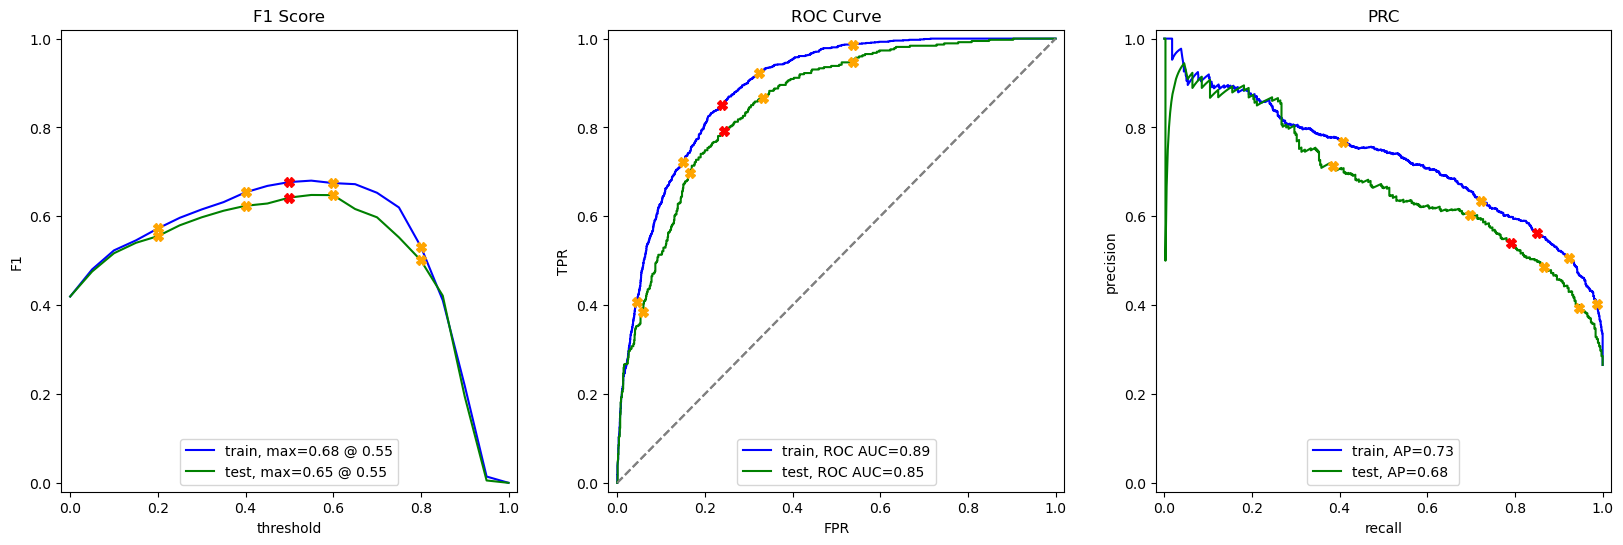

In [21]:
ensemble = VotingClassifier([
    ('xgb', XGBClassifier(eval_metric='auc', random_state=777, n_estimators=50,
                          max_depth=4, learning_rate=0.1, scale_pos_weight=2.768)),
    ('cbc', CatBoostClassifier(verbose=0, random_state=777, depth=4, class_weights=[1, 2.768],
                               iterations=200, loss_function='Logloss')),
], voting='soft')

ensemble.fit(train_features, train_target)

evaluate_model(ensemble, train_features, train_target, test_features, test_target)

**- We've done it! F1 Score: .6415, ROC-AUC: .8516... against new unseen data. Our models actually performed better on new data than it did against the validation set, most likely due to the test set split containing easier to classify observations**

## **Conclusion:**

- XGBClassifier and CatBoostClassifier were powerful models in this project, but were even more powerful when paired together in ensemble. Adding new features with strong target correlation also helped our precision and recall (F1 Score).

***Features added that were beneficial to model predictions:***

- ['high_risk'] = ('payment_method' == 'Electronic check') & ('contract_type' == 'Month-to-Month') & ('paperless_billing' == 1)
- ['low_risk'] = ('tenure_month' >= 12) & ('contract_type' != 'Month-to-Month') & ('paperless_billing' == 0)

***SMOTE/Upsampling/Downsampling were tried, but removed. Utilizing class balancing hyperparamters yielded best results.***

**- In the end we achieved an F1 Score of .6415, and an ROC-AUC of .8516 against the test set utilizing an ensemble stack of XGBClassifier and CatBoostClassifier**

- model details below:

In [22]:
ensemble = VotingClassifier([
    ('xgb', XGBClassifier(eval_metric='auc', random_state=777, n_estimators=50,
                          max_depth=4, learning_rate=0.1, scale_pos_weight=2.768)),
    ('cbc', CatBoostClassifier(verbose=0, random_state=777, depth=4, class_weights=[1, 2.768],
                               iterations=200, loss_function='Logloss')),
], voting='soft')

<div class="alert alert-block alert-danger">
<b>Reviewer's comment v1:</b> </a>


**Congratulations on reaching a solid baseline with your churn prediction model! Your work shows clear effort and understanding of the challenges posed by imbalanced datasets. Achieving a ROC AUC of ~0.85 and an APS of ~0.67 is a strong indicator that your model has good discriminative ability. Well done on getting this far.**

That said, there are important steps you should take to strengthen your project and make it more complete:

### Proper data splitting

You only used a train/test split. For proper evaluation, you should include a validation set

- You should split your dataset into train/validation/test sets (or use cross-validation).

- The validation set is essential for hyperparameter tuning and model selection, while the test set should only be used for final evaluation.

### Explore multiple imbalance-handling techniques

It’s important to compare it against other strategies such as SMOTE, random upsampling, random downsampling, and even the unbalanced baseline. This comparison would demonstrate whether your chosen method is truly the most effective (I saw that you used SMOTE but left it commented out; it’s important to keep it).

- Compare class_weight='balanced' against:

    - SMOTE (synthetic oversampling)

    - Upsampling of churners

    - Downsampling of actives

    - No balancing (baseline)

This comparison would demonstrate whether class_weight is truly the best choice.

### Focus on F1-score and PR AUC, not accuracy

Accuracy is not the best metric in imbalanced problems. F1-score and Precision-Recall AUC are more appropriate because they balance precision and recall, which is critical in churn prediction.

- Accuracy is misleading in imbalanced datasets. Your F1-score of 0.57 is below the recommended threshold (~0.60–0.65). Improving recall for churners should be a priority.


<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v2</b>
 
Thank you for all the changes made. Now you have a much more robust project where you checked different modifications to the data, and now you can indeed confirm which is the best method for class imbalance. You also excelled in meeting the requested range of values. Excellent!



## Solution Report:

**What steps of the plan were performed and what steps were skipped?**

- The first step followed was using ***['customerID']*** as the index to merge all 4 data sets. Since some customers had either phone or internet and not both, this introduced missing values in columns ***['InternetService', 'MultipleLines']***. The second step was to fill missing values with 'No Service', acting as a 3rd option to cover observations where customers paid for one and not the other.

- The only step skipped was adding ***['has_phone', 'has_internet']***, the reason for this was multicollinerity with 'No Service' in the prevously mentioned feature columns. Perfectly correlating columns introduce noise and can negatively impact model performance.

**What difficulties did you encounter and how did you manage to solve them?**

- My models struggled with precision-recall in the first iteration, I also did not include a validation set initially. Feature engineering improved my metrics drastically, using a combination of features that strongly correlated with churn rate, such as ***(contract_type, paperless_billing, tenure_month)***. This pushed my F1 Score into the desired range, as well as improving my primary metric ROC-AUC on the test set.

**What were some of the key steps to solving the task?**

- The largest impacting steps came in the form of feature engineering and dtype simplification. By changing the (Yes/No) columns into (1/0), we eliminated the need for unnecessary (True/False) features when categorical encoding, reducing noise and increasing clarity. Also, by analyzing which combinations of features had disproportionate churn rates, we were able to label high and low risk customers, giving our model an advantage when classifying these positive observations.

**What is your final model and what quality score does it have?**

- My final model is a stack type ensemble consisting of ***XGBClassifier*** and ***CatBoostClassifier***. Both models utilized ***GridSearchCV*** during their individual training, and their optimal parameters against the validation set were then applied to ***VotingClassifier***, which was then tested against the validation set before the test set. The ensemble scored as follows: **(F1 Score = .6415)** & **(ROC-AUC = .8516)**

- Both models utilize class balancing parameters surrounding the number **(2.768)** which represents the ratio of negative:positive observations. This was the winning method for handling class imbalance in this project.

**Final model in code:**

In [ ]:
ensemble = VotingClassifier([
    ('xgb', XGBClassifier(eval_metric='auc', random_state=777, n_estimators=50,
                          max_depth=4, learning_rate=0.1, scale_pos_weight=2.768)),
    ('cbc', CatBoostClassifier(verbose=0, random_state=777, depth=4, class_weights=[1, 2.768],
                               iterations=200, loss_function='Logloss')),
], voting='soft')